**DATA SYNTHESIS AND DATA CLASS**

In [ ]:
import torch
import random

def apply_3d_augmentation(mri_tensor):

    # 1. Random Horizontal/Vertical Flip
    if random.random() > 0.5:
        mri_tensor = torch.flip(mri_tensor, dims=[2]) # Flip depth
    if random.random() > 0.5:
        mri_tensor = torch.flip(mri_tensor, dims=[3]) # Flip height

    # 2. Add Gaussian Noise (Simulates scanner grain/artifacts)
    if random.random() > 0.5:
        noise = torch.randn_like(mri_tensor) * 0.02 # 2% noise level
        mri_tensor = mri_tensor + noise

    # 3. Intensity Scaling (Simulates different lighting/contrast)
    scale_factor = random.uniform(0.9, 1.1)
    mri_tensor = mri_tensor * scale_factor

    return mri_tensor

In [ ]:
import os
import torch
import numpy as np
import random
import torch.nn.functional as F
from torch.utils.data import Dataset
from transformers import DistilBertTokenizer
CLINICAL_REPORTS = {
    0: [
        "Patient presents with mild, episodic tension-type headaches.",
        "Incidental finding during imaging for unrelated minor head trauma.",
        "Neurological examination within normal limits; no focal deficits.",
        "Patient reports occasional dizziness; no history of seizures."
    ],
    1: [
        "History of localized focal seizures managed with medication.",
        "Patient reports progressive dull ache in the cranial region.",
        "Slight motor weakness observed in the contralateral extremities.",
        "Noticeable increase in fatigue and irritability over several months."
    ],
    2: [
        "Emergency presentation following an acute grand mal seizure.",
        "Rapid onset of cognitive disorientation and significant nausea.",
        "Pronounced hemiparesis and speech difficulties noted on admission.",
        "Severe, persistent intracranial pressure symptoms reported by family."
    ]
}

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

class BraTSMultimodalDataset(Dataset):
    def __init__(self, file_paths, mode='train'):
        self.files = file_paths
        self.mode = mode
        self.low_thresh = 5000
        self.high_thresh = 30000
        self.total_brain_voxels = 1500000

    def __len__(self):
        return len(self.files)

    def generate_spiced_pathology(self, label, patient_idx):
        if self.mode == 'test':
            torch.manual_seed(patient_idx)

        canvas = torch.zeros((1, 224, 224))
        num_cells = 400 + (label * 1000)
        indices_h = torch.randint(0, 224, (num_cells,))
        indices_w = torch.randint(0, 224, (num_cells,))
        canvas[0, indices_h, indices_w] = 1.0

        kernel = torch.ones((1, 1, 3, 3)) / 9.0
        pathology = F.conv2d(canvas.unsqueeze(0), kernel, padding=1).squeeze(0)

        if label == 2:
            necrosis_noise = torch.randn(1, 12, 12)
            necrosis_map = F.interpolate(necrosis_noise.unsqueeze(0), size=(224, 224), mode='bilinear').squeeze(0)
            pathology = pathology * torch.sigmoid(necrosis_map * 4)

        return torch.clamp(pathology, 0, 1)

    def __getitem__(self, idx):
        file_path = self.files[idx]
        payload = np.load(file_path)

        mri_data = torch.from_numpy(payload['data']).float()
        if self.mode == 'train':
            mri_data = apply_3d_augmentation(mri_data)
        volume = payload['volume']

        pov = (volume / self.total_brain_voxels) * 100
        margin = 2000
        if volume < (5000 - margin):
          label = 0
        elif volume > (30000 + margin):
          label = 2
        else:
          label = 1 if random.random() > 0.15 else random.choice([0, 2])

        pathology_img = self.generate_spiced_pathology(label, idx)
        if random.random() < 0.20:
            final_text = "Patient data is being processed. Standard follow-up required."
        else:
            final_text = random.choice(CLINICAL_REPORTS[label])

        text_enc = tokenizer(
            final_text,
            padding='max_length',
            truncation=True,
            max_length=48,
            return_tensors="pt"
        )

        return {
            'mri': mri_data,
            'pathology': pathology_img,
            'input_ids': text_enc['input_ids'].squeeze(0),
            'attn_mask': text_enc['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long),
            'pov': torch.tensor(pov, dtype=torch.float32)
        }



**EXAMPLE DATA**

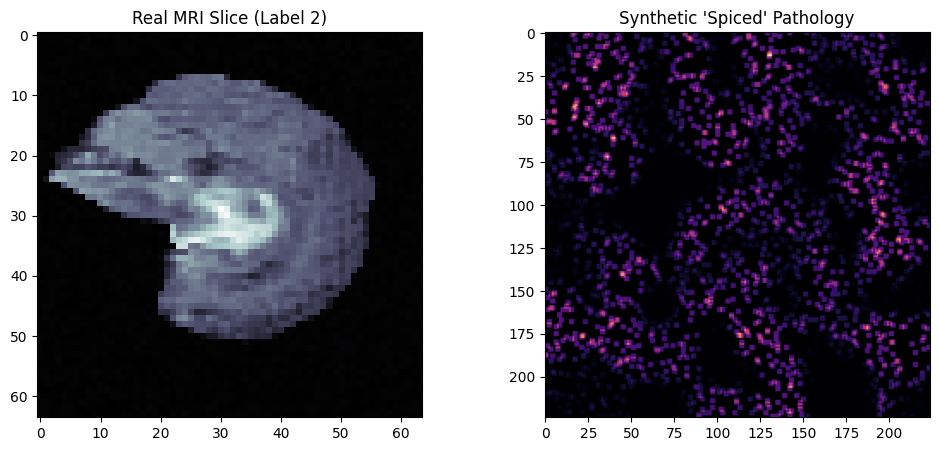


📝 Generated Clinical Report: patient data is being processed. standard follow - up required.
📊 Tumor Volume (Pixels): 211979


In [ ]:
import matplotlib.pyplot as plt
import glob

data_dir = "/content/drive/MyDrive/BraTS_64_Multimodal"
all_files = sorted(glob.glob(f"{data_dir}/*.npz"))
test_ds = BraTSMultimodalDataset(all_files, mode='train')

sample = test_ds[0]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(sample['mri'][0, 32, :, :], cmap='bone')
ax[0].set_title(f"Real MRI Slice (Label {sample['label'].item()})")

ax[1].imshow(sample['pathology'][0], cmap='magma')
ax[1].set_title("Synthetic 'Spiced' Pathology")

plt.show()

decoded_text = tokenizer.decode(sample['input_ids'], skip_special_tokens=True)
print(f"\n📝 Generated Clinical Report: {decoded_text}")
print(f"📊 Tumor Volume (Pixels): {np.load(all_files[0])['volume']}")


**MULTI-MODAL ARCHITECTURE**

In [ ]:
import torch.nn as nn
from transformers import DistilBertModel

class ResearchFusionModel(nn.Module):
    def __init__(self, num_classes=3):
        super(ResearchFusionModel, self).__init__()

        self.mri_tower = nn.Sequential(
            nn.Conv3d(4, 32, 3, stride=2, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            nn.Conv3d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool3d(1),
            nn.Flatten(),
            nn.Linear(64, 256)
        )

        self.path_tower = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(64, 256)
        )

        self.bert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        for param in self.bert.parameters():
            param.requires_grad = False
        self.text_projection = nn.Linear(768, 256)

        self.fusion_block = nn.Sequential(
            nn.Linear(768, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU()
        )

        self.classifier = nn.Linear(256, num_classes)

    def forward(self, mri, path, input_ids, attn_mask):
        f_mri = self.mri_tower(mri)
        f_path = self.path_tower(path)

        with torch.no_grad():
            bert_out = self.bert(input_ids=input_ids, attention_mask=attn_mask)
            f_text_raw = bert_out.last_hidden_state[:, 0, :]
        f_text = self.text_projection(f_text_raw)

        combined = torch.cat((f_mri, f_path, f_text), dim=1)

        fused_features = self.fusion_block(combined)

        return self.classifier(fused_features)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = ResearchFusionModel().to(device)

Using device: cpu


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

train_files, val_files = train_test_split(all_files, test_size=0.3, random_state=42)

train_ds = BraTSMultimodalDataset(train_files, mode='train')
val_ds = BraTSMultimodalDataset(val_files, mode='test')

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

print(f"Train Mode Enabled for {len(train_ds)} samples.")
print(f"Test Mode Enabled for {len(val_ds)} samples.")

Train Mode Enabled for 257 samples.
Test Mode Enabled for 111 samples.


**TRAINING (without DROPOUT)**

In [ ]:
import torch.optim as optim
from tqdm.auto import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

best_model_path = "/content/drive/MyDrive/best_multimodal_model.pth"

def train_model(model, train_loader, val_loader, epochs=20):
    best_val_acc = 0.0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]")
        for batch in loop:
            mri = batch['mri'].to(device)
            path = batch['pathology'].to(device)
            ids = batch['input_ids'].to(device)
            mask = batch['attn_mask'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(mri, path, ids, mask)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

            loop.set_postfix(loss=loss.item(), acc=100.*correct_train/total_train)

        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for batch in val_loader:
                mri, path = batch['mri'].to(device), batch['pathology'].to(device)
                ids, mask = batch['input_ids'].to(device), batch['attn_mask'].to(device)
                labels = batch['label'].to(device)

                outputs = model(mri, path, ids, mask)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_acc = 100 * correct_val / total_val
        print(f"Epoch {epoch+1} Summary: Train Acc: {100*correct_train/total_train:.2f}% | Val Acc: {val_acc:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "/content/drive/MyDrive/best_multimodal_model.pth")
            print(f"New Best Model Saved with {val_acc:.2f}% Accuracy")

    print("Training Complete.")

train_model(model, train_loader, val_loader, epochs=15)

Epoch [1/15]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1 Summary: Train Acc: 85.55% | Val Acc: 90.99%
⭐ New Best Model Saved with 90.99% Accuracy


Epoch [2/15]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 2 Summary: Train Acc: 96.48% | Val Acc: 90.09%


Epoch [3/15]:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 13 Summary: Train Acc: 100.00% | Val Acc: 100.00%


Epoch [14/15]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 14 Summary: Train Acc: 100.00% | Val Acc: 100.00%


Epoch [15/15]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 15 Summary: Train Acc: 100.00% | Val Acc: 100.00%
Training Complete.


--- Classification Report ---
              precision    recall  f1-score   support

     Grade 0       1.00      1.00      1.00         2
     Grade 1       1.00      1.00      1.00         9
     Grade 2       1.00      1.00      1.00       100

    accuracy                           1.00       111
   macro avg       1.00      1.00      1.00       111
weighted avg       1.00      1.00      1.00       111



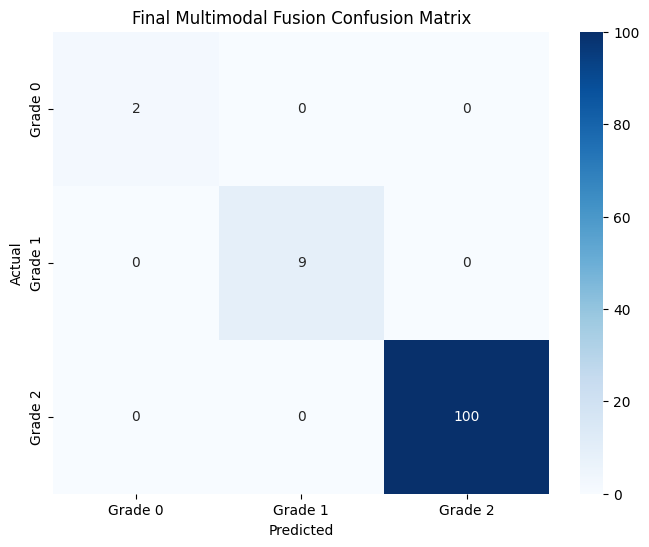

In [ ]:
def evaluate_and_plot(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            mri, path = batch['mri'].to(device), batch['pathology'].to(device)
            ids, mask = batch['input_ids'].to(device), batch['attn_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(mri, path, ids, mask)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("--- Classification Report ---")
    print(classification_report(all_labels, all_preds,
                                labels=[0, 1, 2],
                                target_names=['Grade 0', 'Grade 1', 'Grade 2'],
                                zero_division=0))
    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2])
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Grade 0', 'Grade 1', 'Grade 2'],
                yticklabels=['Grade 0', 'Grade 1', 'Grade 2'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Final Multimodal Fusion Confusion Matrix')
    plt.show()

evaluate_and_plot(model, val_loader)

In [ ]:
model = ResearchFusionModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


**MODALITY DEPENDENCE TEST WITHOUT DROPOUT**

--- MRI-ONLY ABLATION REPORT ---
              precision    recall  f1-score   support

     Grade 0       0.02      1.00      0.04         2
     Grade 1       0.00      0.00      0.00        10
     Grade 2       0.00      0.00      0.00        99

    accuracy                           0.02       111
   macro avg       0.01      0.33      0.01       111
weighted avg       0.00      0.02      0.00       111



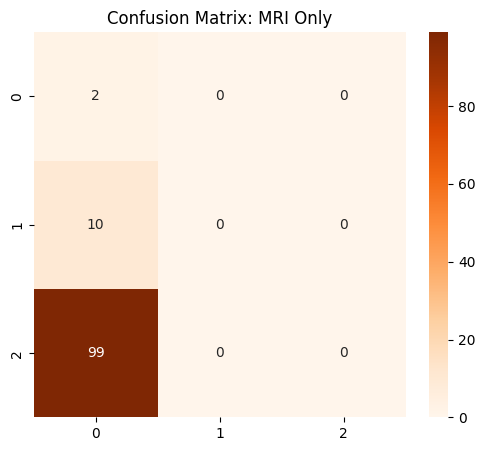

In [ ]:
def evaluate_mri_only(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            mri = batch['mri'].to(device)
            labels = batch['label'].to(device)

            blank_pathology = torch.zeros_like(batch['pathology']).to(device)

            empty_ids = torch.zeros_like(batch['input_ids']).to(device)
            empty_mask = torch.zeros_like(batch['attn_mask']).to(device)

            outputs = model(mri, blank_pathology, empty_ids, empty_mask)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("--- MRI-ONLY ABLATION REPORT ---")
    print(classification_report(all_labels, all_preds,
                                labels=[0, 1, 2],
                                target_names=['Grade 0', 'Grade 1', 'Grade 2'],
                                zero_division=0))

    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
    plt.title('Confusion Matrix: MRI Only')
    plt.show()

# Run the test
evaluate_mri_only(model, val_loader)

In [ ]:
def run_full_ablation(model, loader):
    model.eval()

    for mode in ['Pathology-Only', 'Text-Only']:
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in loader:
                labels = batch['label'].to(device)

                if mode == 'Pathology-Only':
                    mri = torch.zeros_like(batch['mri']).to(device)
                    path = batch['pathology'].to(device)
                    ids = torch.zeros_like(batch['input_ids']).to(device)
                    mask = torch.zeros_like(batch['attn_mask'].to(device))
                else:
                    mri = torch.zeros_like(batch['mri']).to(device)
                    path = torch.zeros_like(batch['pathology']).to(device)
                    ids = batch['input_ids'].to(device)
                    mask = batch['attn_mask'].to(device)

                outputs = model(mri, path, ids, mask)
                _, predicted = torch.max(outputs, 1)

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        print(f"\n--- {mode} ABLATION REPORT ---")
        print(classification_report(all_labels, all_preds, labels=[0, 1, 2],
                                    target_names=['Grade 0', 'Grade 1', 'Grade 2'],
                                    zero_division=0))

run_full_ablation(model, val_loader)


--- Pathology-Only ABLATION REPORT ---
              precision    recall  f1-score   support

     Grade 0       1.00      1.00      1.00         2
     Grade 1       0.00      0.00      0.00        11
     Grade 2       0.90      1.00      0.95        98

    accuracy                           0.90       111
   macro avg       0.63      0.67      0.65       111
weighted avg       0.81      0.90      0.85       111


--- Text-Only ABLATION REPORT ---
              precision    recall  f1-score   support

     Grade 0       0.00      0.00      0.00       0.0
     Grade 1       0.00      0.00      0.00      12.0
     Grade 2       0.00      0.00      0.00      99.0

    accuracy                           0.00     111.0
   macro avg       0.00      0.00      0.00     111.0
weighted avg       0.00      0.00      0.00     111.0



**TRAINING WITH DROPOUT**

In [ ]:
import torch.optim as optim
from tqdm.auto import tqdm
import random

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

best_model_path = "/content/drive/MyDrive/best_multimodal_model.pth"

def train_model(model, train_loader, val_loader, epochs=20, dropout_prob=0.15):
    best_val_acc = 0.0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]")
        for batch in loop:
            mri = batch['mri'].to(device)
            path = batch['pathology'].to(device)
            ids = batch['input_ids'].to(device)
            mask = batch['attn_mask'].to(device)
            labels = batch['label'].to(device)

            if random.random() < dropout_prob:
                choice = random.choice(['mri', 'path', 'text'])
                if choice == 'mri':
                    mri = torch.zeros_like(mri)
                elif choice == 'path':
                    path = torch.zeros_like(path)
                else:
                    ids = torch.zeros_like(ids)
                    mask = torch.zeros_like(mask)

            optimizer.zero_grad()
            outputs = model(mri, path, ids, mask)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

            loop.set_postfix(loss=loss.item(), acc=100.*correct_train/total_train)

        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for batch in val_loader:
                mri, path = batch['mri'].to(device), batch['pathology'].to(device)
                ids, mask = batch['input_ids'].to(device), batch['attn_mask'].to(device)
                labels = batch['label'].to(device)

                outputs = model(mri, path, ids, mask)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_acc = 100 * correct_val / total_val
        print(f"Epoch {epoch+1} Summary: Train Acc: {100*correct_train/total_train:.2f}% | Val Acc: {val_acc:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"⭐ New Best Model Saved with {val_acc:.2f}% Accuracy")

    print("Training Complete.")

train_model(model, train_loader, val_loader, epochs=15)

Epoch [1/15]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1 Summary: Train Acc: 80.47% | Val Acc: 89.19%
⭐ New Best Model Saved with 89.19% Accuracy


Epoch [2/15]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 2 Summary: Train Acc: 95.70% | Val Acc: 90.99%
⭐ New Best Model Saved with 90.99% Accuracy


Epoch [3/15]:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 13 Summary: Train Acc: 99.61% | Val Acc: 100.00%


Epoch [14/15]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 14 Summary: Train Acc: 99.61% | Val Acc: 100.00%


Epoch [15/15]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 15 Summary: Train Acc: 100.00% | Val Acc: 100.00%
Training Complete.


Testing MRI-Only Performance after Dropout Training...
--- MRI-ONLY ABLATION REPORT ---
              precision    recall  f1-score   support

     Grade 0       0.00      0.00      0.00         0
     Grade 1       0.00      0.00      0.00        13
     Grade 2       0.88      1.00      0.94        98

    accuracy                           0.88       111
   macro avg       0.29      0.33      0.31       111
weighted avg       0.78      0.88      0.83       111



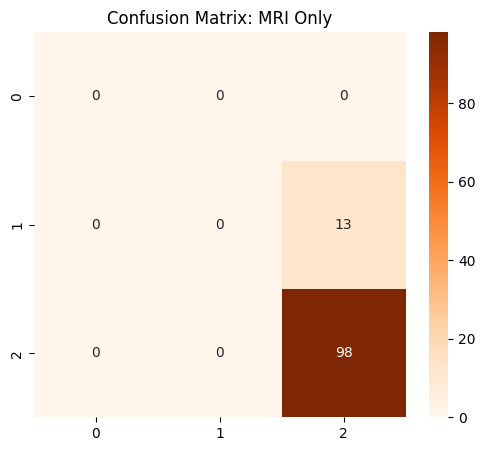

In [ ]:
model.load_state_dict(torch.load("/content/drive/MyDrive/best_multimodal_model.pth"))
model.to(device)

print("Testing MRI-Only Performance after Dropout Training...")
evaluate_mri_only(model, val_loader)

In [ ]:
def run_post_dropout_ablation(model, loader):
    model.eval()

    for mode in ['Pathology-Only', 'Text-Only']:
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in loader:
                labels = batch['label'].to(device)

                if mode == 'Pathology-Only':
                    mri = torch.zeros_like(batch['mri']).to(device)
                    path = batch['pathology'].to(device)
                    ids = torch.zeros_like(batch['input_ids']).to(device)
                    mask = torch.zeros_like(batch['attn_mask']).to(device)
                else:
                    mri = torch.zeros_like(batch['mri']).to(device)
                    path = torch.zeros_like(batch['pathology']).to(device)
                    ids = batch['input_ids'].to(device)
                    mask = batch['attn_mask'].to(device)

                outputs = model(mri, path, ids, mask)
                _, predicted = torch.max(outputs, 1)

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        print(f"\n--- {mode} POST-DROPOUT ABLATION ---")
        print(classification_report(all_labels, all_preds, labels=[0, 1, 2],
                                    target_names=['Grade 0', 'Grade 1', 'Grade 2'],
                                    zero_division=0))

run_post_dropout_ablation(model, val_loader)


--- Pathology-Only POST-DROPOUT ABLATION ---
              precision    recall  f1-score   support

     Grade 0       0.00      0.00      0.00         0
     Grade 1       0.00      0.00      0.00        13
     Grade 2       0.88      1.00      0.94        98

    accuracy                           0.88       111
   macro avg       0.29      0.33      0.31       111
weighted avg       0.78      0.88      0.83       111


--- Text-Only POST-DROPOUT ABLATION ---
              precision    recall  f1-score   support

     Grade 0       0.00      0.00      0.00         2
     Grade 1       0.00      0.00      0.00        11
     Grade 2       0.88      1.00      0.94        98

    accuracy                           0.88       111
   macro avg       0.29      0.33      0.31       111
weighted avg       0.78      0.88      0.83       111

